##### ============================================================                                                 
##### Logistic Regression on Mobile Price Classification                                                           
##### Target: price_range (0, 1, 2, 3) -> multi-class problem                                                      
##### ============================================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

In [3]:
# 1. Load data ------------------------------------------------
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
print(df.head())
print("\nTarget distribution:\n", df["price_range"].value_counts().sort_index())

Shape: (2000, 21)
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_sc

In [4]:
# 2. Features / target ---------------------------------------
X = df.drop(columns=["price_range"])
y = df["price_range"]

In [5]:
# 3. Train / test split --------------------------------------
# stratify=y -> keeps class proportions equal in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# 4. Feature scaling -----------------------------------------
# Logistic regression is sensitive to feature scale because
# gradient descent / L-BFGS converges much faster when features
# have similar magnitudes. RAM (thousands) vs clock_speed (~2.0)
# would otherwise dominate the gradient.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)   # use TRAIN stats only

In [ ]:
# 5. Train logistic regression -------------------------------
# multi_class='multinomial' -> softmax (one model, K outputs)
# solver='lbfgs'            -> good default for small/medium data
# C=1.0                     -> inverse of L2 regularization
# max_iter=1000             -> let it converge
model = LogisticRegression(
    multi_class="multinomial",#---------------
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=42,
    
)
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi


Test accuracy : 0.965
5-fold CV mean: 0.94625 +/- 0.006959705453537519

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



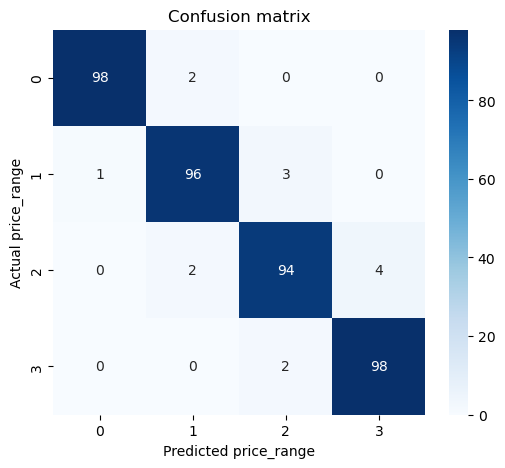

In [9]:
# 6. Evaluate ------------------------------------------------
y_pred = model.predict(X_test_s)
print("\nTest accuracy :", accuracy_score(y_test, y_pred))

cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring="accuracy")
print("5-fold CV mean:", cv_scores.mean(), "+/-", cv_scores.std())

print("\nClassification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel("Predicted price_range")
plt.ylabel("Actual price_range")
plt.title("Confusion matrix")
plt.show()

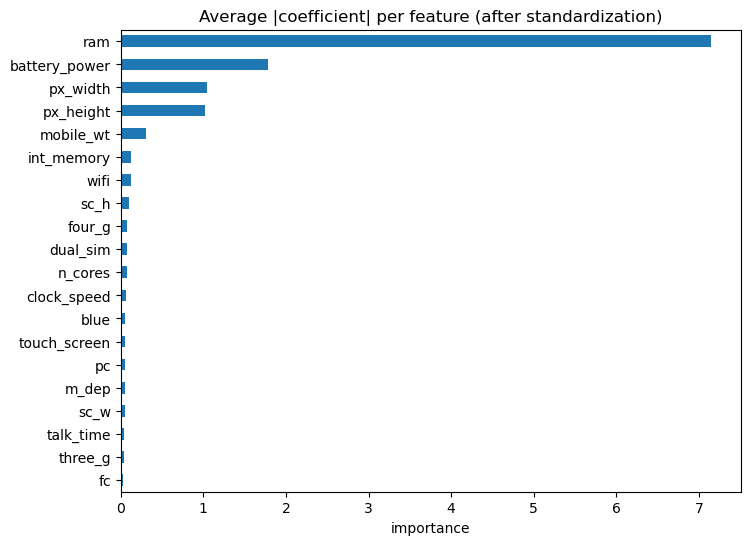


Top features:
 ram              7.147931
battery_power    1.782751
px_width         1.048843
px_height        1.015026
mobile_wt        0.306240
int_memory       0.126567
wifi             0.124381
sc_h             0.100494
dtype: float64


In [10]:
# 7. Which features matter? ----------------------------------
# coef_ has shape (n_classes, n_features). We average absolute
# weight across classes to rank feature importance.
importance = pd.Series(
    np.mean(np.abs(model.coef_), axis=0),
    index=X.columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Average |coefficient| per feature (after standardization)")
plt.xlabel("importance")
plt.show()
print("\nTop features:\n", importance.head(8))

In [17]:
df0 = pd.read_csv("train.csv")
df0.corr()["price_range"].sort_values(ascending=False)

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [11]:
# 8. Predict on the unseen test.csv --------------------------
test_df = pd.read_csv("test.csv")
test_ids = test_df["id"] if "id" in test_df.columns else None
X_unseen = test_df.drop(columns=["id"], errors="ignore")
X_unseen_s = scaler.transform(X_unseen)

unseen_pred = model.predict(X_unseen_s)
out = pd.DataFrame({"price_range": unseen_pred})
if test_ids is not None:
    out.insert(0, "id", test_ids)
out.to_csv("predictions.csv", index=False)
print("\nSaved predictions.csv")
print(out.head())


Saved predictions.csv
   id  price_range
0   1            2
1   2            3
2   3            2
3   4            3
4   5            1
